# WO06 -- core-share exploration for the Lovejoy-region coherence badge

Notebook-only. No engine, API, or UI code changes come out of this notebook directly --
see `docs/design/_workbench/coherence_study_opus.md` (full spec) and
`docs/edop/workbench/workplan_africa.md` (WO06 summary). The shipped dispersion badge
(`coherence_iqr`, `59bfcea`) stays exactly as-is until a separate, later WO retires it.

**Why.** The shipped badge tests weighted IQR (p75-p25) < 20 on a region's per-basin
percentile scores. IQR counts inward from both ends, so a lopsided (skewed) distribution's
upper edge can land inside a thin tail and inflate the width even when the bulk of the mass
is tight. Confirmed live before this notebook was started: `snd_pc_sav`/`snd_pc_uav`
(visually near-identical, bulk-left/thin-tail-right) receive opposite badges for real
regions (Rivers: concentrated 12.74 / spread 20.88; North Coast: concentrated 15.79 /
spread 29.05).

**Proposed alternative -- core share.** The fraction of a region's weighted area falling
inside the densest window of fixed half-width delta on the global percentile (rank) axis.
Tail-immune by construction (material outside the window subtracts equally regardless of
how far out it lies).

**Naming note.** Core share as defined is a fixed-width relative of the shorth /
highest-density-interval family (shortest interval containing a fixed *mass*; core share
fixes the *width* and reports the mass instead). Worth confirming the write-up below uses
that established vocabulary rather than re-deriving it under a new name.

**Structure**: Part A (A1 compute, A4 tie/NaN validity checks -- run before interpreting
anything else, A2 stability, A3 visual validation against IQR), then Part B (exploratory
region-level profile, no threshold adopted).


In [1]:
# Cell 1
%matplotlib inline
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapely.geometry
from scipy.stats import spearmanr
from IPython.display import Image as IPImage, display

from scripts.shared import db_utils
from scripts.shared.db_utils import db_connect
from scripts.edop.areas.engine import (
    load_catalog,
    resolve_polygon,
    attach_values,
    aggregate_b1,
    weighted_quantile,
    _BLOCK1_CLUSTERS,
    _LEVEL_TABLE,
    _LEVEL_VIEW,
)

ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop' / 'workbench'
OUT.mkdir(parents=True, exist_ok=True)

LEVEL = 6
DELTAS = [10, 15, 20]

print(f"OUT = {OUT}")


OUT = /Users/karlg/Documents/repos/_edops/output/edop/workbench


In [2]:
# Cell 2
# Geometry: read the already-built, served lovejoy_regions.geojson directly -- one source
# of truth (same file the /api/lovejoy-signature route reads), no whg_staging touch here.
conn = db_connect()

geojson_path = ROOT / 'app' / 'static' / 'workbench' / 'lovejoy_regions.geojson'
lovejoy = json.loads(geojson_path.read_text())

regions = {}   # src_id -> {name, macro, geom_wkt}
for feat in lovejoy['features']:
    p = feat['properties']
    regions[p['src_id']] = {
        'name':     p['name'],
        'macro':    p['macro'],
        'geom_wkt': shapely.geometry.shape(feat['geometry']).wkt,
    }

print(f"{len(regions)} Lovejoy regions loaded from {geojson_path.name}")


34 Lovejoy regions loaded from lovejoy_regions.geojson


In [3]:
# Cell 3
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

# Per-region: resolve the L6 basin set, attach percentile-score + raw-value matrices, and run
# aggregate_b1 (the exact shipped function -- same iqr/p10/p90/coherence the badge uses, no
# hand re-derivation). Cached in region_data so every later cell reuses this without re-hitting
# the DB. Expect ~1.5-4s/region (measured in WO05); ~2 min total for 34 regions.
meta_df = load_catalog(level=LEVEL)
table   = _LEVEL_TABLE[LEVEL]
view    = _LEVEL_VIEW[LEVEL]

region_data = {}   # src_id -> {basin_set, matrix_df, raw_df, b1_rows (dict by variable), n_units}
skipped = []       # src_id with zero L6 basin coverage (small offshore island groups, per WO05)

for src_id, r in regions.items():
    basin_set = resolve_polygon(r['geom_wkt'], f'{LEVEL:02d}', conn)
    if basin_set.empty:
        skipped.append(src_id)
        continue
    matrix_df, class_id_df, raw_df = attach_values(basin_set, meta_df, conn, table, view)
    b1_rows = {row['variable']: row for row in aggregate_b1(basin_set, matrix_df, meta_df)}
    region_data[src_id] = {
        'basin_set': basin_set,
        'matrix_df': matrix_df,
        'raw_df':    raw_df,
        'b1_rows':   b1_rows,
        'n_units':   len(basin_set),
    }
    print(f"{src_id:8s} {r['name']:28s} {len(basin_set):4d} basins")

print()
print(f"{len(region_data)} regions resolved, {len(skipped)} skipped (no L6 coverage): {skipped}")


hc_67    Gulf Islands                    1 basins

31 regions resolved, 3 skipped (no L6 coverage): ['hc_40', 'hc_44', 'hc_45']


## Part A -- does core share track visual reading?

### A1. Compute

Scope: **27** B1 continuous variables in **bands A/B/C/E** -- physical geography only.
B1's full continuous set (`kind == 'continuous'`, `typology_cluster` in
`{continental-gradient, scale-dependent}`) is 34 vars across A/B/C/D/E; the 7 Band D
(Anthropocene) variables -- cropland/pasture extent, human footprint, pop density -- are
excluded (Karl, 2026-09-05): whether a region coheres in human land-use pattern is a
different question from whether it coheres environmentally, and EDOPS generally treats
A-C/E/T as the physical-geography bands. (B5's separate, short extreme-variable list --
e.g. `river_area` -- is also out of scope here; a natural follow-on if this generalizes.)

**Data source note.** `/api/lovejoy-signature`'s `detail.distribution` histogram
(`engine.py :: _weighted_histogram`) bins over each region's own local `[min, max]` score
range at a fixed 20 bins -- not the global `[0, 100]` rank axis a 1-rank sliding window
needs. So this notebook works from the raw per-basin weighted scores (`matrix_df` joined to
`basin_set`'s weights, masked + normalized -- the same three lines `aggregate_b1` runs
internally), not the API payload.


In [14]:
# Cell 4
# Bands A/B/C/E (physical geography) only -- Band D is Anthropocene (human land-use:
# cropland/pasture extent, human footprint, pop density), a different kind of "coherence"
# question than whether a region holds together environmentally. Karl, 2026-09-05: A-C, E,
# and T are the bands most of EDOPS treats as physical-geography-relevant; D is out of scope
# here. Drops 7 of 34 B1 continuous vars, leaving 27 (A:7, B:12, C:7, E:1).
b1_meta = meta_df[(meta_df['kind'] == 'continuous')
                   & (meta_df['typology_cluster'].isin(_BLOCK1_CLUSTERS))
                   & (meta_df['band'] != 'D')]
B1_VARS = list(b1_meta.index)
print(f"{len(B1_VARS)} B1 continuous variables in scope (bands A/B/C/E, D excluded)")
print(b1_meta['band'].value_counts().sort_index().to_string())


def scores_weights(basin_set, matrix_df, api_key):
    """Per-basin (score, normalized weight) for one variable in one region -- same
    mask/join/normalize `aggregate_b1` runs internally, exposed here for reuse across
    variables without recomputing badge rows.

    Returns (scores, wts_norm) as float arrays, or (None, None) if no valid coverage.
    """
    bs = basin_set.set_index('hybas_id') if 'hybas_id' in basin_set.columns else basin_set.copy()
    bs = bs.copy()
    bs.index = bs.index.astype('int64')
    md = matrix_df.copy()
    md.index = md.index.astype('int64')

    joined = bs[['weight']].join(md, how='inner')
    col = pd.to_numeric(joined[api_key], errors='coerce')
    w = joined['weight']
    mask = col.notna()

    scores = col[mask].values.astype(float)
    wts = w[mask].values.astype(float)
    coverage = wts.sum()
    if len(scores) == 0 or coverage == 0:
        return None, None
    return scores, wts / coverage


def core_share(scores, wts_norm, delta, step=1):
    """Max weighted share inside any window of width 2*delta on [0, 100], slid at
    `step`-rank increments (no mode estimation, no tie-breaking -- exhaustive scan).

    Returns (best_share, window_lo, window_hi). window_lo is None if scores is empty.
    """
    if scores is None or len(scores) == 0:
        return 0.0, None, None
    positions = np.arange(0, 100 - 2 * delta + step, step)
    best_share, best_lo = 0.0, None
    for lo in positions:
        hi = lo + 2 * delta
        share = wts_norm[(scores >= lo) & (scores <= hi)].sum()
        if share > best_share:
            best_share, best_lo = share, lo
    return float(best_share), (float(best_lo) if best_lo is not None else None), \
        (float(best_lo) + 2 * delta if best_lo is not None else None)


27 B1 continuous variables in scope (bands A/B/C/E, D excluded)
band
A     7
B    12
C     7
E     1


In [32]:
# Cell 5
# Exclusion has two distinct reasons, kept separate because they generalize differently:
#
# 1. n_units == 1 (production fidelity): the shipped pipeline suppresses the coherence badge
#    entirely for true single-basin regions (engine.py's _backfill_single_basin_raw, run
#    inside areal_signature_polygon right after aggregate_b1 -- a step this notebook's direct
#    aggregate_b1 call bypasses). Including them would misrepresent what the UI actually shows.
#
# 2. n_units < MIN_BASINS (statistical floor, not a production behavior): Canarias (n=2) is
#    not suppressed in production, but empirically produced degenerate results twice --
#    identical Spearman rho across two different delta-pairs in A2, then dominated 100% of
#    Cell 12's "agreed-tight" control panel with trivially-tied 2-basin scores (2026-09-05).
#    With this few points, core_share and IQR are both close to guaranteed to read "perfectly
#    tight" regardless of what the region actually looks like -- not informative for this
#    study either way. MIN_BASINS=5 is a round choice; the dataset has a natural gap here
#    (0/1/1/2 basins for the smallest four regions, then a jump to 25), so any reasonable
#    small threshold is equivalent in this dataset.
#
# Karl, 2026-09-05: this generalizes beyond the notebook -- a future badge redesign may need
# to tag (or outright suppress) low-basin-count regions rather than force any dispersion
# statistic to behave well at n=2; exact mechanism TBD, not this WO's job.
MIN_BASINS = 5
excluded_regions = {sid for sid, data in region_data.items() if data['n_units'] < MIN_BASINS}

records = []
for src_id, data in region_data.items():
    if src_id in excluded_regions:
        continue
    basin_set, matrix_df, b1_rows = data['basin_set'], data['matrix_df'], data['b1_rows']
    for api_key in B1_VARS:
        row = b1_rows.get(api_key)
        if row is None or row.get('coherence') is None:
            continue   # no_data or outside_active_domain -- nothing to compare
        scores, wts_norm = scores_weights(basin_set, matrix_df, api_key)
        if scores is None:
            continue
        det = row['detail']
        for delta in DELTAS:
            share, lo, hi = core_share(scores, wts_norm, delta)
            records.append({
                'src_id': src_id, 'region': regions[src_id]['name'], 'variable': api_key,
                'band': row['band'], 'delta': delta,
                'core_share': share, 'window_lo': lo, 'window_hi': hi,
                'iqr': det['iqr'], 'p10': det['p10'], 'p90': det['p90'],
                'coherence_iqr': row['coherence'],
                'n_basins': row['n_units'], 'total_weight': data['n_units'],
            })

core_share_df = pd.DataFrame.from_records(records)
out_path = OUT / 'wo06_core_share.tsv'
core_share_df.to_csv(out_path, sep='\t', index=False)

# One combined print -- PyCharm's console can silently drop/overwrite an earlier print() when
# a cell fires several in a row (documented project-wide gotcha, same mechanism as "figure
# output overwrites text output"; confirmed here 2026-09-05: the exclusion line vanished when
# printed separately before the row-count line). Ganging into one call is the fix, not a
# workaround -- there's no reliable way to guarantee ordering across separate print() calls.
summary_lines = [
    f"Excluding {len(excluded_regions)} region(s) with fewer than {MIN_BASINS} basins: "
    f"{[(regions[s]['name'], region_data[s]['n_units']) for s in excluded_regions]}",
    f"{len(core_share_df)} rows ({core_share_df['src_id'].nunique()} regions x "
    f"{core_share_df['variable'].nunique()} variables x {len(DELTAS)} deltas) -> {out_path}",
    core_share_df.head(9).to_string(),
]
print("\n\n".join(summary_lines))


Excluding 3 region(s) with fewer than 5 basins: [('Canarias', 2), ('Gulf Islands', 1), ('Comoros', 1)]

2160 rows (28 regions x 26 variables x 3 deltas) -> /Users/karlg/Documents/repos/_edops/output/edop/workbench/wo06_core_share.tsv

  src_id     region          variable band  delta  core_share  window_lo  window_hi    iqr    p10    p90 coherence_iqr  n_basins  total_weight
0  hc_01  Northwest           aridity    C     10    0.645943        8.0       28.0  14.94  10.03  37.41  concentrated       132           132
1  hc_01  Northwest           aridity    C     15    0.884767        8.0       38.0  14.94  10.03  37.41  concentrated       132           132
2  hc_01  Northwest           aridity    C     20    0.959774        7.0       47.0  14.94  10.03  37.41  concentrated       132           132
3  hc_01  Northwest  aridity_upstream    C     10    0.717883       12.0       32.0  15.56   9.95  34.26  concentrated       132           132
4  hc_01  Northwest  aridity_upstream    C     15 

### A4. Ties and NoData -- check before interpreting anything

Two possible bugs that would corrupt every number above. **Read the printed results before
running A2/A3** -- if either check turns up a real problem, stop and report it rather than
proceeding to rank or plot on a corrupted axis.

1. Does the global percentile transform (`PERCENT_RANK()` in `engine.py :: rank_expr`) spread
   tied raw values across an interval, or give them one shared score? (Reading the SQL: SQL's
   `PERCENT_RANK` uses `RANK()`-style tie handling -- equal values get the identical rank --
   so it should *not* spread. Confirmed empirically below, not just from reading the code.)
2. Are NoData basins (`-9999`/`NULL`) excluded from both the weight sum and the window count,
   rather than contributing at any rank?


In [25]:
# Cell 6 -- A4, tie check
# Pick the highest zero_fraction B1 variables (biggest expected tie blocks) and, across every
# cached region, group basins by raw value and check the score's spread *within* each raw-value
# group. If PERCENT_RANK shares one score per tie (expected), within-group score range == 0
# everywhere. raw_df and matrix_df are both indexed by api_key + hybas_id, so no db_col lookup
# needed.
tie_check_vars = b1_meta.sort_values('zero_fraction', ascending=False).head(4).index.tolist()
print(f"Tie-check variables (highest zero_fraction): {tie_check_vars}")
print()

worst_spread = 0.0
worst_ctx = None
largest_tie_block = 0
for api_key in tie_check_vars:
    for src_id, data in region_data.items():
        raw_df, matrix_df = data['raw_df'], data['matrix_df']
        if api_key not in raw_df.columns or api_key not in matrix_df.columns:
            continue
        both = pd.DataFrame({'raw': raw_df[api_key], 'score': matrix_df[api_key]}).dropna()
        if both.empty:
            continue
        grouped = both.groupby('raw')['score'].agg(['nunique', 'count', lambda s: s.max() - s.min()])
        grouped.columns = ['n_unique_scores', 'n_basins', 'score_range']
        tie_groups = grouped[grouped['n_basins'] > 1]
        if tie_groups.empty:
            continue
        largest_tie_block = max(largest_tie_block, int(tie_groups['n_basins'].max()))
        max_spread_here = float(tie_groups['score_range'].max())
        if max_spread_here > worst_spread:
            worst_spread = max_spread_here
            worst_ctx = (api_key, src_id, int(tie_groups['n_basins'].max()))

print(f"Largest tie block found (any variable/region): {largest_tie_block} basins sharing one raw value")
print(f"Worst within-tie-block score range found: {worst_spread:.6f}"
      f"{'' if worst_spread == 0 else f'  <-- NOT ZERO, see {worst_ctx}'}")
print()
print("PASS: ties share one score, not spread." if worst_spread == 0
      else "FAIL: tie spreading detected -- stop, do not run A2/A3 until this is resolved.")


Tie-check variables (highest zero_fraction): ['permafrost_extent', 'karst', 'karst_upstream', 'wet_pct_grp2']

Largest tie block found (any variable/region): 438 basins sharing one raw value
Worst within-tie-block score range found: 0.000000

PASS: ties share one score, not spread.


In [26]:
# Cell 7 -- A4, NaN/NoData check
# Confirm raw NoData (-9999 or NULL) basins never carry a score, and never survive into
# scores_weights()'s masked output. attach_values() should already convert -9999 -> NaN in
# raw_df (view-level), but check the sentinel too in case a variable bypasses that path.
# Build the (raw, score) pair as one DataFrame first (pandas aligns dict-of-Series by index
# automatically) rather than comparing raw_df[api_key] and matrix_df[api_key] as bare Series --
# direct Series `==` requires identically-labeled indices and raises instead of aligning,
# which is what errored here.
mismatches = []
for api_key in B1_VARS:
    for src_id, data in region_data.items():
        raw_df, matrix_df = data['raw_df'], data['matrix_df']
        if api_key not in raw_df.columns or api_key not in matrix_df.columns:
            continue
        both = pd.DataFrame({
            'raw':   pd.to_numeric(raw_df[api_key], errors='coerce'),
            'score': matrix_df[api_key],
        })
        raw_is_nodata = (both['raw'].isna() | (both['raw'] == -9999)).values
        score_is_nan = both['score'].isna().values
        if not (raw_is_nodata == score_is_nan).all():
            n_bad = int((raw_is_nodata != score_is_nan).sum())
            mismatches.append((api_key, src_id, n_bad))

print(f"NoData/score mismatches found: {len(mismatches)}")
if mismatches:
    print(mismatches[:10])

# Spot-check scores_weights() itself never returns a NoData basin for one B1 var/region.
sample_src, sample_data = next(iter(region_data.items()))
sample_var = B1_VARS[0]
raw = pd.to_numeric(sample_data['raw_df'][sample_var], errors='coerce')
n_nodata_raw = int((raw.isna() | (raw == -9999)).sum())
scores, wts_norm = scores_weights(sample_data['basin_set'], sample_data['matrix_df'], sample_var)
n_returned = len(scores) if scores is not None else 0
print()
print(f"Spot check ({sample_var}, {sample_src}): {n_nodata_raw} NoData raw basins, "
      f"{n_returned} returned by scores_weights() out of {sample_data['n_units']} total "
      f"({sample_data['n_units'] - n_nodata_raw} expected)")
print()
print("PASS: NoData excluded from both score and weight." if not mismatches
      else "FAIL: NoData leakage detected -- stop, do not run A2/A3 until this is resolved.")


NoData/score mismatches found: 0

Spot check (aridity, hc_01): 0 NoData raw basins, 132 returned by scores_weights() out of 132 total (132 expected)

PASS: NoData excluded from both score and weight.


### A2. Stability across delta

Only proceed past this point if both A4 checks above printed PASS.

Rank the variables by core share within each region, separately at each delta, and check
the correlation between those orderings. Stable ordering across delta means delta is a
legibility choice, not a source of disagreement; churn means the distributions are too
irregular for a one-number summary and that is a valid, reportable negative outcome.


In [27]:
# Cell 8
# Per region: Spearman correlation between the variable ranking at delta=10 vs 15, and 15 vs 20.
delta_pairs = [(10, 15), (15, 20), (10, 20)]
stability_records = []
for src_id, g in core_share_df.groupby('src_id'):
    piv = g.pivot(index='variable', columns='delta', values='core_share')
    for d1, d2 in delta_pairs:
        if d1 not in piv.columns or d2 not in piv.columns:
            continue
        pair = piv[[d1, d2]].dropna()
        if len(pair) < 3:
            continue
        rho, _ = spearmanr(pair[d1], pair[d2])
        stability_records.append({'src_id': src_id, 'region': regions[src_id]['name'],
                                   'delta_pair': f'{d1}-{d2}', 'spearman_rho': rho, 'n_vars': len(pair)})

stability_df = pd.DataFrame.from_records(stability_records)
print(stability_df.groupby('delta_pair')['spearman_rho'].describe().to_string())
print()
low = stability_df[stability_df['spearman_rho'] < 0.7].sort_values('spearman_rho')
print(f"{len(low)} region/delta-pair combos with rho < 0.7 (ordering churns):")
print(low.to_string() if len(low) else "(none)")


            count      mean       std       min       25%       50%       75%       max
delta_pair                                                                             
10-15        28.0  0.920622  0.037603  0.835015  0.901287  0.921222  0.950586  0.979056
10-20        28.0  0.842022  0.072069  0.672949  0.805043  0.864137  0.901794  0.932022
15-20        28.0  0.930992  0.052761  0.761865  0.926754  0.949412  0.960422  0.983906

2 region/delta-pair combos with rho < 0.7 (ordering churns):
   src_id              region delta_pair  spearman_rho  n_vars
5   hc_02      Western Sahara      10-20      0.672949      26
68  hc_24  West Central South      10-20      0.674195      26


### A3. Where the two statistics disagree

Pick one delta for the rest of Part A (the one A2 showed as most stable / most legible;
default to 15 -- the middle value -- unless A2 says otherwise). Scatter core share against
IQR, then hand-inspect the strongest disagreements against the histogram as it actually
renders in the UI. **Acceptance gate: Karl's own eye against this panel, not another
metric.**


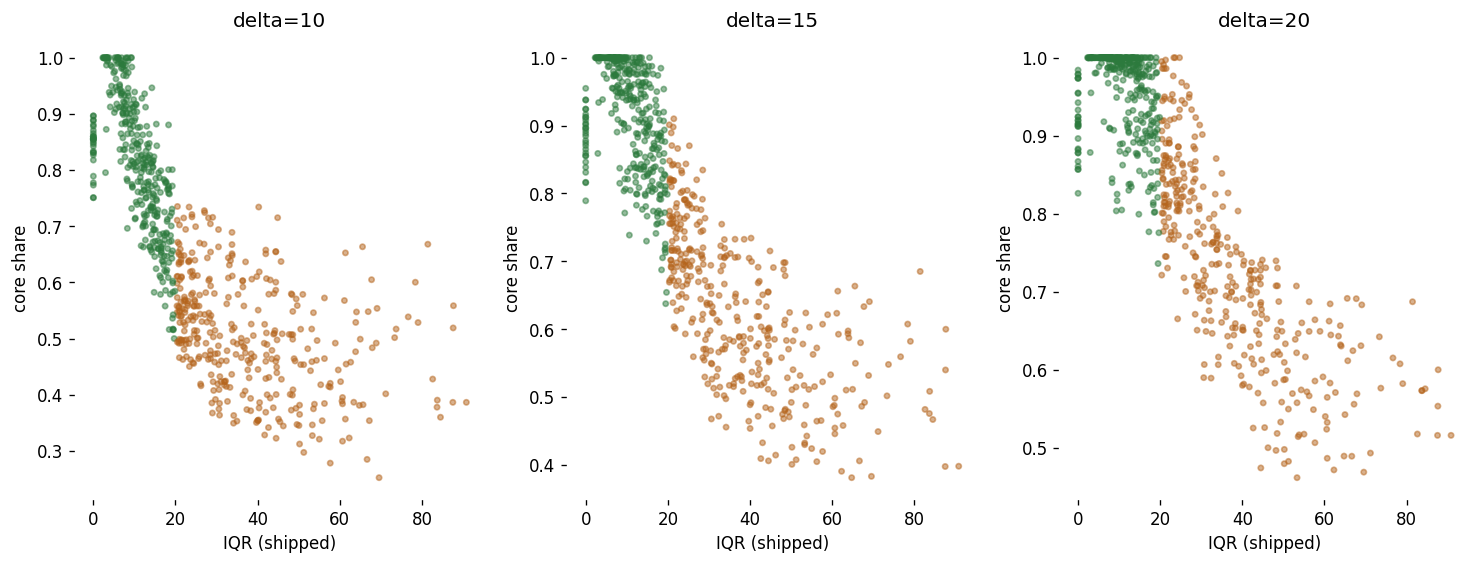

In [28]:
# Cell 9
DELTA_MAIN = 15   # revisit after reading A2's output above

print("drawing core_share vs iqr scatter...")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')
for ax, delta in zip(axes, DELTAS):
    d = core_share_df[core_share_df['delta'] == delta]
    ax.set_facecolor('white')
    colors = d['coherence_iqr'].map({'concentrated': '#2c7a3d', 'spread': '#b5651d'})
    ax.scatter(d['iqr'], d['core_share'], s=10, alpha=0.5, c=colors)
    ax.set_title(f"delta={delta}", color='black')
    ax.set_xlabel('IQR (shipped)', color='black')
    ax.set_ylabel('core share', color='black')
    ax.tick_params(colors='black')
outpath = OUT / 'wo06_a3_scatter.png'
fig.savefig(outpath, facecolor='white', dpi=120, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(outpath)))


In [29]:
# Cell 10
# Disagreement = gap between the two statistics' percentile-rank "tightness" within this
# dataset (core_share: higher = tighter; iqr: lower = tighter, so its rank is inverted before
# comparing). The interesting off-diagonal case this study exists to catch: tight core share
# (high pct) with wide IQR (also high pct after inversion) -- skew.
d = core_share_df[core_share_df['delta'] == DELTA_MAIN].copy()
d['core_share_pct'] = d['core_share'].rank(pct=True)
d['iqr_tightness_pct'] = (-d['iqr']).rank(pct=True)   # invert: low iqr -> high pct
d['disagreement'] = (d['core_share_pct'] - d['iqr_tightness_pct']).abs()

top20 = d.sort_values('disagreement', ascending=False).head(20)

# Force in the two regions where the motivating pct_sand/pct_sand_upstream disagreement was
# empirically confirmed before this notebook started (Rivers hc_05, North Coast hc_10) --
# not every region carrying that variable pair (34 of them), which is what the first pass of
# this cell did and blew the inspection set out to 78 rows / an unreadable 16-row histogram
# grid in Cell 11. The spec's intent was "the motivating case, regardless of rank," singular.
MOTIVATING_REGIONS = ['hc_05', 'hc_10']
motivating = d[d['src_id'].isin(MOTIVATING_REGIONS) & d['variable'].isin(['pct_sand', 'pct_sand_upstream'])]
inspection_set = pd.concat([top20, motivating]).drop_duplicates(subset=['src_id', 'variable'])

print(f"Top 20 disagreements (delta={DELTA_MAIN}) + motivating pct_sand/pct_sand_upstream "
      f"rows from Rivers/North Coast ({len(inspection_set)} total to inspect):")
print(inspection_set[['region', 'variable', 'core_share', 'iqr', 'coherence_iqr', 'disagreement']]
      .sort_values('disagreement', ascending=False).to_string())


Top 20 disagreements (delta=15) + motivating pct_sand/pct_sand_upstream rows from Rivers/North Coast (24 total to inspect):
                   region               variable  core_share    iqr coherence_iqr  disagreement
1408           East Coast         karst_upstream    0.789139   0.00  concentrated      0.486111
1840             Kalahari  wet_pct_grp1_upstream    0.815787   0.00  concentrated      0.437500
1846             Kalahari  wet_pct_grp2_upstream    0.816413   0.00  concentrated      0.434722
1837             Kalahari           wet_pct_grp1    0.831023   0.00  concentrated      0.406944
1762   West Central South  wet_pct_grp1_upstream    0.838524   0.00  concentrated      0.386111
865       Central Savanna                  karst    0.846218   0.00  concentrated      0.370833
1141                 Horn           wet_pct_grp1    0.855274   0.00  concentrated      0.363889
178       Western Savanna         karst_upstream    0.855596   0.00  concentrated      0.362500
2071  Southe

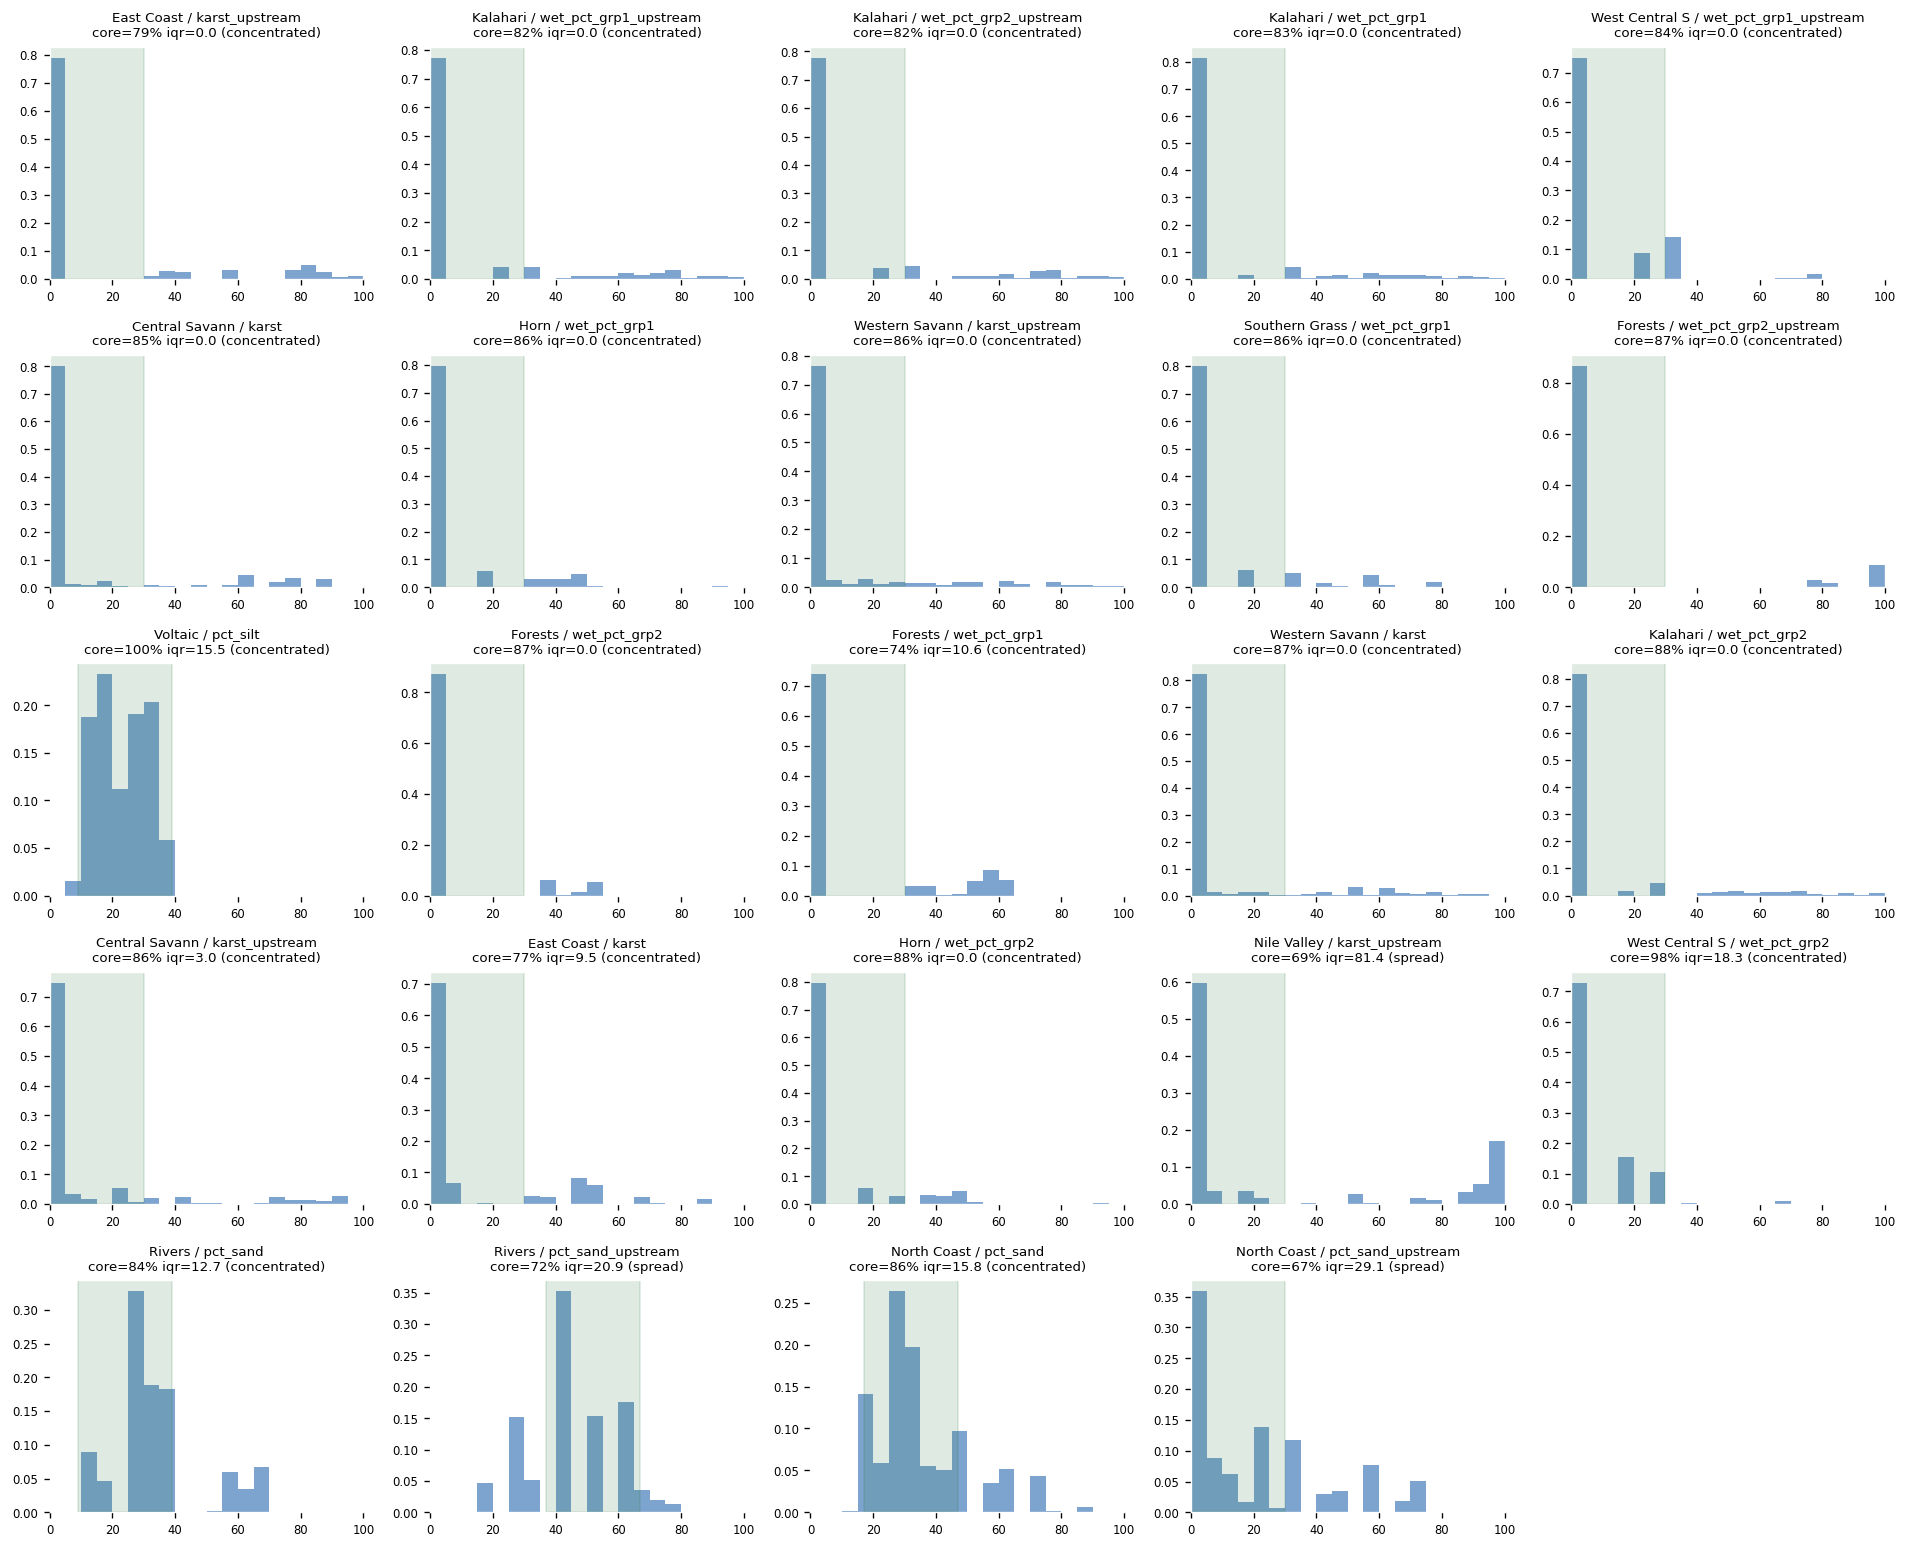

In [30]:
# Cell 11
# Annotated histogram per disagreement: weighted score distribution on the fixed [0,100]
# global rank axis (the axis core share and IQR both operate on -- more legible here than the
# UI's per-region-local-range histogram), with the winning core-share window shaded and both
# numbers + the shipped badge in the title.
rows_to_plot = inspection_set.sort_values('disagreement', ascending=False).to_dict('records')
n = len(rows_to_plot)
ncols = 5
nrows = -(-n // ncols)

print(f"drawing {n} annotated disagreement histograms...")
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows))
fig.patch.set_facecolor('white')
axes = np.atleast_1d(axes).flatten()

for ax, rec in zip(axes, rows_to_plot):
    ax.set_facecolor('white')
    scores, wts_norm = scores_weights(
        region_data[rec['src_id']]['basin_set'], region_data[rec['src_id']]['matrix_df'], rec['variable'])
    ax.hist(scores, bins=20, range=(0, 100), weights=wts_norm, color='#5b8dc4', alpha=0.8)
    if rec['window_lo'] is not None:
        ax.axvspan(rec['window_lo'], rec['window_hi'], color='#2c7a3d', alpha=0.15)
    ax.set_title(f"{rec['region'][:14]} / {rec['variable']}\n"
                 f"core={rec['core_share']:.0%} iqr={rec['iqr']:.1f} ({rec['coherence_iqr']})",
                 fontsize=8, color='black')
    ax.set_xlim(0, 100)
    ax.tick_params(labelsize=7, colors='black')

for ax in axes[n:]:
    ax.axis('off')

fig.tight_layout()
outpath = OUT / 'wo06_a3_disagreements.png'
fig.savefig(outpath, facecolor='white', dpi=120, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(outpath)))


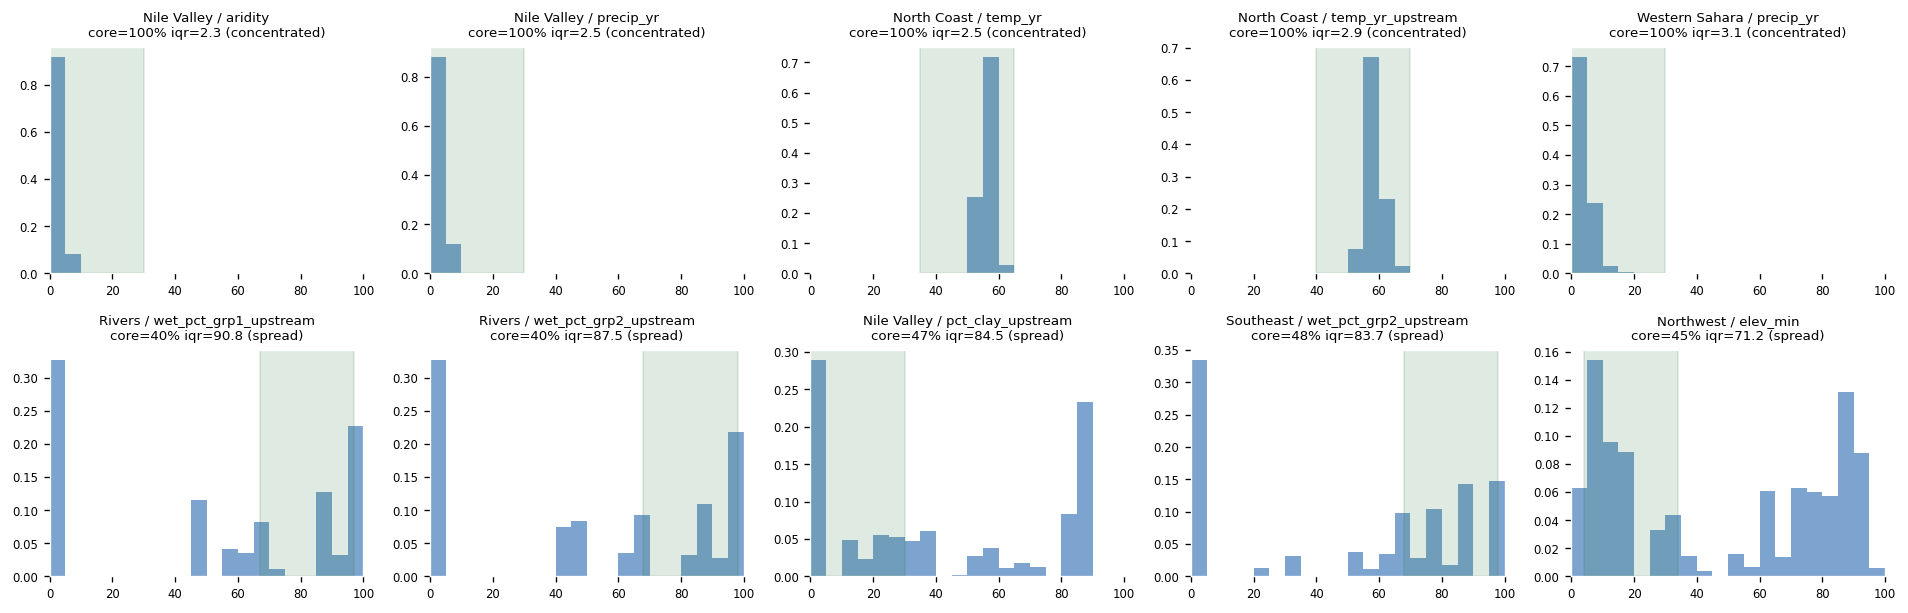

In [31]:
# Cell 12
# Control panel: ~10 pairs where the two statistics agree, split tight/broad, so the visual
# comparison isn't drawn only from cases pre-selected for disagreement.
agree = d.sort_values('disagreement').head(200)   # most-agreeing pool to split from
agreed_tight = agree[agree['coherence_iqr'] == 'concentrated'].nsmallest(5, 'iqr')
agreed_broad = agree[agree['coherence_iqr'] == 'spread'].nlargest(5, 'iqr')
control_set = pd.concat([agreed_tight, agreed_broad]).to_dict('records')

print(f"drawing {len(control_set)} agreement-control histograms...")
fig, axes = plt.subplots(2, 5, figsize=(3.2 * 5, 2.6 * 2))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for ax, rec in zip(axes, control_set):
    ax.set_facecolor('white')
    scores, wts_norm = scores_weights(
        region_data[rec['src_id']]['basin_set'], region_data[rec['src_id']]['matrix_df'], rec['variable'])
    ax.hist(scores, bins=20, range=(0, 100), weights=wts_norm, color='#5b8dc4', alpha=0.8)
    if rec['window_lo'] is not None:
        ax.axvspan(rec['window_lo'], rec['window_hi'], color='#2c7a3d', alpha=0.15)
    ax.set_title(f"{rec['region'][:14]} / {rec['variable']}\n"
                 f"core={rec['core_share']:.0%} iqr={rec['iqr']:.1f} ({rec['coherence_iqr']})",
                 fontsize=8, color='black')
    ax.set_xlim(0, 100)
    ax.tick_params(labelsize=7, colors='black')

for ax in axes[len(control_set):]:
    ax.axis('off')

fig.tight_layout()
outpath = OUT / 'wo06_a3_control.png'
fig.savefig(outpath, facecolor='white', dpi=120, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(outpath)))


## Part B -- region-level profile (exploratory, no gate)

No threshold is being adopted here -- this exists to show whether a region-level
interpretive move ("on how many, and which, dimensions does a declared region actually
cohere environmentally?") has anything to say before any of it is built. Uses
`DELTA_MAIN` and a provisional core-share cutoff, both clearly labeled as such.


In [33]:
# Cell 13
CUTOFF = 0.5   # provisional -- "coherent on this variable" if core_share >= CUTOFF at DELTA_MAIN

d_main = core_share_df[core_share_df['delta'] == DELTA_MAIN].copy()
d_main['coherent'] = d_main['core_share'] >= CUTOFF

per_region = d_main.groupby(['src_id', 'region']).agg(
    n_variables=('variable', 'count'),
    n_coherent=('coherent', 'sum'),
    n_basins=('n_basins', 'first'),
).reset_index()
per_region['pct_coherent'] = per_region['n_coherent'] / per_region['n_variables']
per_region = per_region.sort_values('n_coherent', ascending=False)

print(f"Regions ranked by count of variables clearing core_share >= {CUTOFF} "
      f"(delta={DELTA_MAIN}), most to least environmentally coherent:")
print(per_region.to_string(index=False))

# By band, per region
by_band = d_main.groupby(['src_id', 'region', 'band'])['coherent'].sum().unstack(fill_value=0)
print()
print("By band:")
print(by_band.to_string())


Regions ranked by count of variables clearing core_share >= 0.5 (delta=15), most to least environmentally coherent:
src_id              region  n_variables  n_coherent  n_basins  pct_coherent
 hc_29          Madagascar           26          26        80      1.000000
 hc_28 Southern Grasslands           26          26        90      1.000000
 hc_23  West Central North           26          26       111      1.000000
 hc_12      Central Sahara           26          26       438      1.000000
 hc_02      Western Sahara           26          26       434      1.000000
 hc_24  West Central South           26          25        42      0.961538
 hc_07             Voltaic           26          25        49      0.961538
 hc_15           Northeast           26          24       278      0.923077
 hc_27           Southeast           26          24        49      0.923077
 hc_21        East Central           24          24       115      1.000000
 hc_19         Great Lakes           26         

In [34]:
# Cell 14
# Which variables do the coherence work -- if a handful of variables carry most regions'
# coherence, or if soil/terrain vars cohere while hydrology doesn't, that is a finding about
# the Lovejoy vocabulary, not about the statistic.
per_variable = d_main.groupby(['variable', 'band']).agg(
    n_regions=('coherent', 'count'),
    n_coherent_regions=('coherent', 'sum'),
    mean_core_share=('core_share', 'mean'),
).reset_index()
per_variable['pct_regions_coherent'] = per_variable['n_coherent_regions'] / per_variable['n_regions']
per_variable = per_variable.sort_values('pct_regions_coherent', ascending=False)

print("Variables ranked by share of regions where they clear the coherence cutoff:")
print(per_variable.to_string(index=False))
print()
print("By band, mean % of regions coherent:")
print(per_variable.groupby('band')['pct_regions_coherent'].mean().sort_values(ascending=False).to_string())


Variables ranked by share of regions where they clear the coherence cutoff:
             variable band  n_regions  n_coherent_regions  mean_core_share  pct_regions_coherent
              aridity    C         28                  28         0.870935              1.000000
             pct_sand    B         28                  28         0.752937              1.000000
     temp_yr_upstream    C         28                  28         0.934280              1.000000
              temp_yr    C         28                  28         0.935891              1.000000
               runoff    B         28                  28         0.813122              1.000000
     aridity_upstream    C         28                  28         0.835069              1.000000
             pct_silt    B         28                  28         0.965355              1.000000
    pct_silt_upstream    B         28                  28         0.929977              1.000000
    pct_sand_upstream    B         28              

In [37]:
# Cell 15
# Does coherence track region size? If strongly, any future cutoff has to control for it --
# the honest display may be a region's position relative to comparable-sized regions, not an
# absolute count.
#
# Split into its own cell, no figure (2026-09-05): the combined print immediately before
# plt.subplots in the same cell was confirmed to render zero text at all in PyCharm -- not a
# missed scroll, not stale output (fresh 55ms execution). Putting text and figure in separate
# cells is the actual fix; the print-before-figure "anchor" convention isn't sufficient on its
# own. Also writing the numbers to a file as a second, independent record.
rho_count, p_count = spearmanr(per_region['n_basins'], per_region['n_coherent'])
rho_pct, p_pct = spearmanr(per_region['n_basins'], per_region['pct_coherent'])

stats_text = "\n".join([
    f"n_basins vs n_coherent (raw count):      rho={rho_count:.3f}  p={p_count:.4f}",
    f"n_basins vs pct_coherent (normalized):    rho={rho_pct:.3f}  p={p_pct:.4f}",
])
stats_path = OUT / 'wo06_b_size_vs_coherence_stats.txt'
stats_path.write_text(stats_text + "\n")
print(stats_text)
print(f"-> {stats_path}")


n_basins vs n_coherent (raw count):      rho=-0.091  p=0.6467
n_basins vs pct_coherent (normalized):    rho=-0.175  p=0.3732
-> /Users/karlg/Documents/repos/_edops/output/edop/workbench/wo06_b_size_vs_coherence_stats.txt


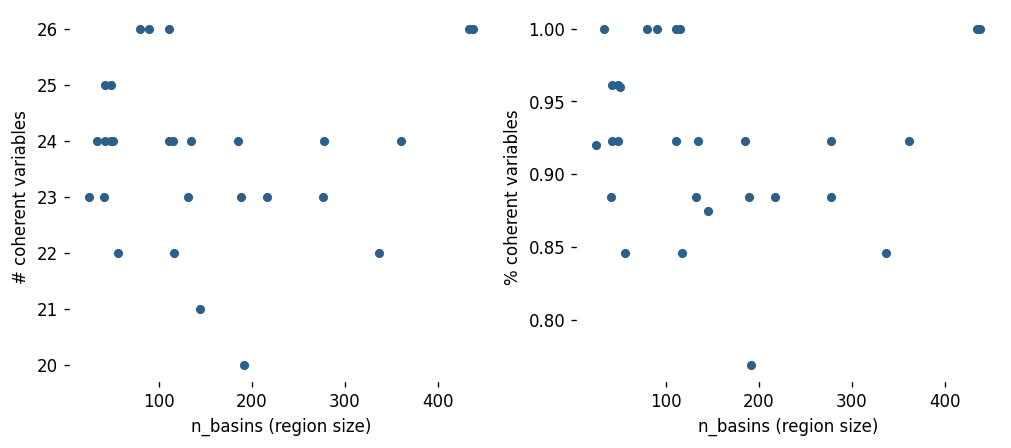

In [38]:
# Cell 16
print("drawing region size vs coherence...")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.patch.set_facecolor('white')
for ax, ycol, ylabel in zip(axes, ['n_coherent', 'pct_coherent'], ['# coherent variables', '% coherent variables']):
    ax.set_facecolor('white')
    ax.scatter(per_region['n_basins'], per_region[ycol], s=20, color='#2c5f8a')
    ax.set_xlabel('n_basins (region size)', color='black')
    ax.set_ylabel(ylabel, color='black')
    ax.tick_params(colors='black')
outpath = OUT / 'wo06_b_size_vs_coherence.png'
fig.savefig(outpath, facecolor='white', dpi=120, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(outpath)))


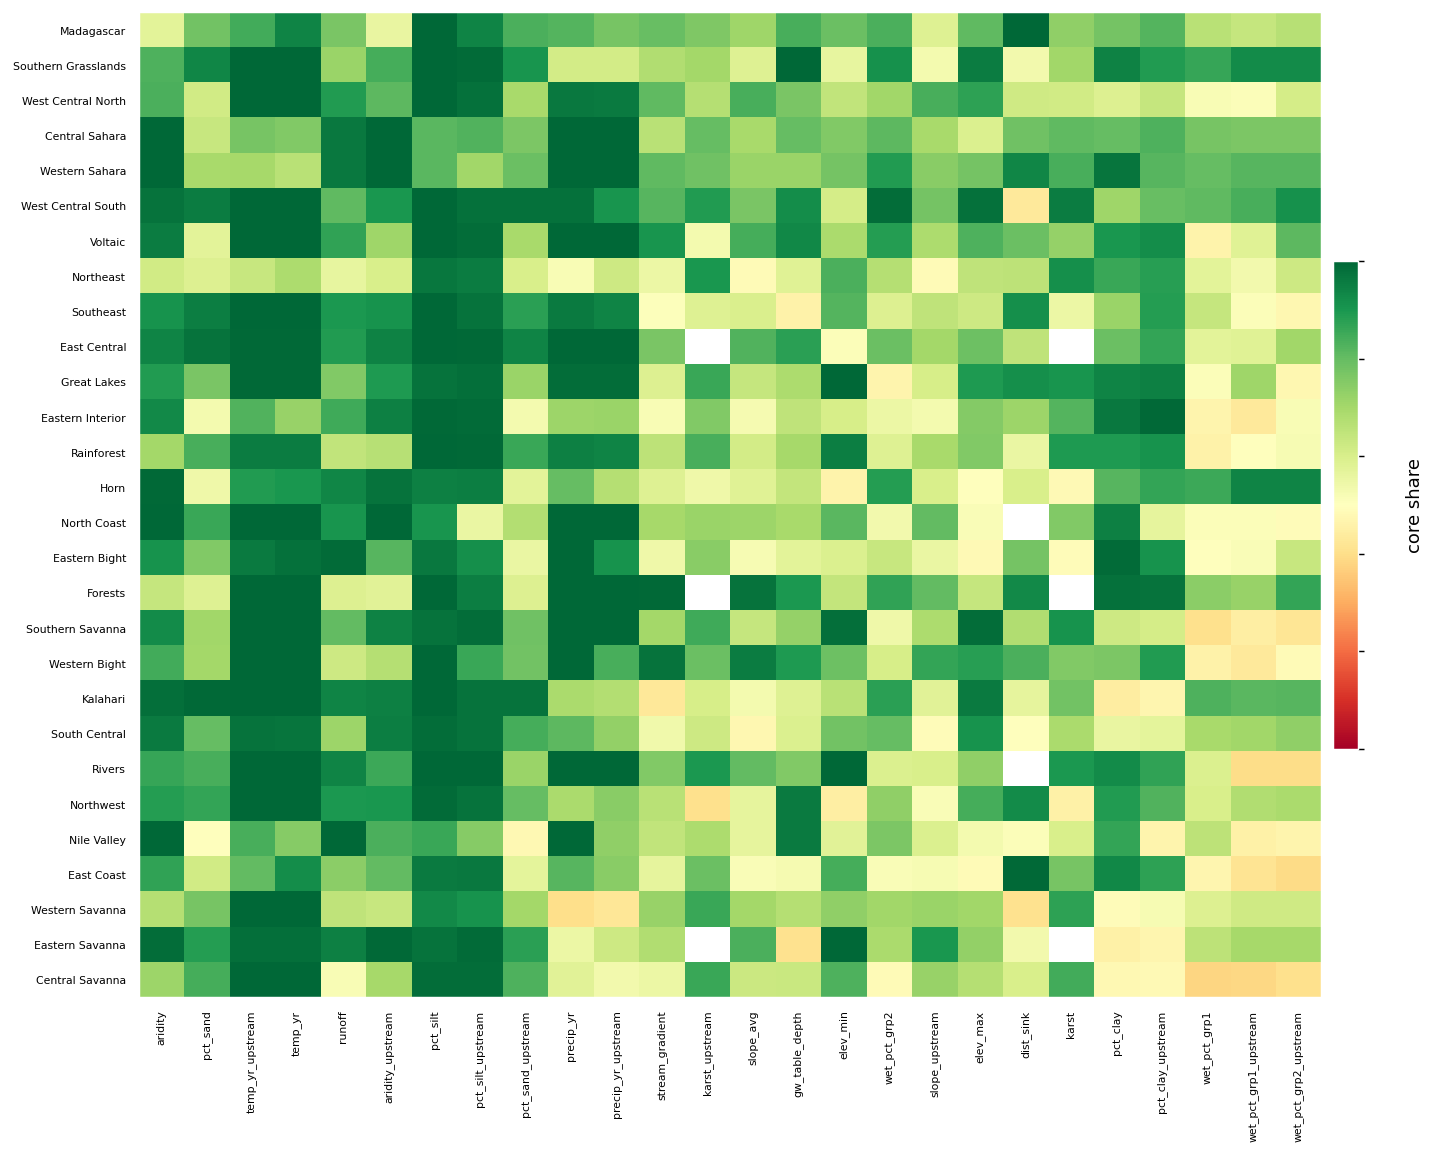

In [39]:
# Cell 17
# Regions x variables heatmap, shaded by core share -- the artifact most likely to be legible
# at Braga scale. Rows ordered by per_region's coherence ranking (Cell 13); columns by
# per_variable's coherence ranking (Cell 14), so structure (if any) reads on both axes.
region_order = per_region['region'].tolist()
var_order = per_variable['variable'].tolist()
heat = d_main.pivot(index='region', columns='variable', values='core_share').reindex(
    index=region_order, columns=var_order)

print("drawing regions x variables core-share heatmap...")
fig, ax = plt.subplots(figsize=(0.35 * len(var_order) + 3, 0.28 * len(region_order) + 2))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(var_order)))
ax.set_xticklabels(var_order, rotation=90, fontsize=6, color='black')
ax.set_yticks(range(len(region_order)))
ax.set_yticklabels(region_order, fontsize=6, color='black')
cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label('core share', color='black')
cbar.ax.yaxis.set_tick_params(color='black')
outpath = OUT / 'wo06_b_heatmap.png'
fig.savefig(outpath, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(outpath)))


## Wrap-up

**Part A gate**: review Cell 11 (disagreements) against Cell 12 (control) by eye. If core
share tracks your reading where IQR does not, Part A passes and a follow-on WO would propose
the display change (still not this notebook's job). If it doesn't, that's the deliverable --
report it as such.

**A3 finding (2026-09-05, Karl's read of Cell 11): the binary concentrated/spread vocabulary
is missing a third category, not just misapplying the two it has.** 19 of the 24 inspected
disagreements share one visual signature: a large point-mass at rank 0 (most basins genuinely
have none of the thing -- karst, wetland) plus a real, non-trivial minority scattered from
~40-100. IQR reads these as `concentrated` with **IQR = 0.0** every time -- once the tied mass
at one value exceeds half the region's weight, both p25 and p75 land on it by construction,
so IQR is blind to whatever the remaining minority looks like, no matter how real it is. Core
share (79-89% for these) at least signals "most, not all."

Two names for two different things here, worth keeping straight in any write-up: **zero-
inflated** is the standard term for the *mechanism* (a point-mass at one value mixed with a
separate non-zero population); **long-tailed** is the closer lay description of *what the
residual looks like*, though technically imprecise for several of these panels, where the
residual isn't a smoothly-decaying tail but a scattered comb of similarly-sized bars spread
across a wide range -- closer to "spike plus scattered remainder" than a classic long tail.

This is a finding for whoever scopes the follow-on WO, not something to solve here: the
eventual fix may not be "swap IQR for core share" alone, but "the badge needs a third state"
(e.g. concentrated / long-tailed(-or-zero-inflated) / spread), which core share's window
position (`window_lo`/`window_hi`) plus its share could plausibly distinguish (a window
anchored at 0 vs. floating) but this notebook doesn't attempt that classification.

**Low-basin-count finding (2026-09-05).** Canarias (2 basins) independently produced
degenerate results twice -- identical Spearman rho across two delta-pairs in A2, then all 5
of Cell 12's "agreed-tight" control examples -- purely because 2 points trivially tie/fit any
window, not because anything about the region is genuinely informative. Cell 5 now excludes
regions with fewer than 5 basins, separately from the `n_units==1` production-fidelity
exclusion. Karl's broader point: this generalizes past this notebook -- a future badge
redesign likely needs to handle low-basin-count regions explicitly (a different statistic, or
a tag/suppression the way `n_units==1` already gets suppressed) rather than expect any single
dispersion statistic to behave meaningfully at n=2. Mechanism TBD, not this WO's job.

**Part B finding -- no significant region-size effect (2026-09-05).** Spearman rho between
`n_basins` and coherence: -0.091 (p=0.65) for raw count, -0.175 (p=0.37) for the normalized
percentage -- neither significant, both negligible. The scope doc's own concern ("if the
relationship is strong, any future cutoff has to account for it... the honest display may be
a region's position relative to comparable-sized regions rather than an absolute number")
doesn't hold up in this dataset: region size (25-438 basins here) doesn't meaningfully predict
coherence in either direction. Matches the earlier eyeball -- Western/Central Sahara (the two
largest, ~434-438 basins) both score perfectly; Central Savanna, the single worst performer,
is mid-sized (192). A plain coherence count/percentage looks usable without size-normalization
at this scale.

**Deferred, untouched by this WO** (per the spec): reference-distribution question (raw vs.
rank), threshold derivation, marginal-basin trimming, `two_regime` interaction.

**Not done in this pass** -- flag if wanted: B5's short extreme-variable list (out of A1's
scope, see the note there); a formal write-up of the A2/A3 findings back into
`docs/design/_workbench/coherence_study_opus.md` or a `wo06_findings.md`.
